In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

from sklearn.model_selection import train_test_split,
# StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler

# Data splitting
from sklearn.model_selection import train_test_split

# Pipeline
from sklearn.pipeline import Pipeline


# Models
from sklearn.linear_model import LogisticRegression
# from sklearn.tree import DecisionTreeClassifier

# from sklearn.svm import SVC
# from sklearn.neighbors import KNeighborsClassifier

# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# # Evaluation
# from sklearn.metrics import (
#     accuracy_score,
#     precision_score,
#     recall_score,
#     f1_score,
#     roc_auc_score,
#     classification_report,
#     average_precision_score,
#     confusion_matrix
# )

# # Optional: XGBoost
# from xgboost import XGBClassifier
# import joblib


In [263]:
# configurations
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="darkgrid")

plt.rcParams.update({
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
})

RANDOM_STATE = 42
CSV_PATH = "customer_churn_data.csv"          # update path for a different dataset
TARGET_COL = "Churn" # target column name

In [264]:
real_data = pd.read_excel("Online Retail.xlsx")

In [265]:
real_data.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.550,17850.000,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.390,17850.000,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.750,17850.000,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.390,17850.000,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.390,17850.000,United Kingdom


In [266]:
real_data.shape

(541909, 8)

**preprocessing**

**same as customer segmentation project since its the same data**

In [267]:
df_clean = real_data.copy()

df_clean = df_clean.drop_duplicates()

df_clean = df_clean.dropna(subset=["CustomerID"])

df_clean = df_clean[
    ~df_clean["InvoiceNo"].astype(str).str.startswith("C")
]

df_clean = df_clean[
    (df_clean["Quantity"] > 0) &
    (df_clean["UnitPrice"] > 0)
].copy()

df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

df_clean["TotalPrice"] = (
    df_clean["Quantity"] * df_clean["UnitPrice"]
)

In [268]:
df_clean.shape

(392692, 9)

In [269]:
df_clean["InvoiceDate"].agg(["min", "max"])

min   2010-12-01 08:26:00
max   2011-12-09 12:50:00
Name: InvoiceDate, dtype: datetime64[ns]

## Time-Based Churn Split

We split the data into two periods to predict customer churn without data leakage:

- **Past / Observation Period:** December 2010 → September 2011 (≈ 10 months)
  - Used to calculate customer behavior and features.

- **Future / Churn Period:** October 2011 → November 2011 (2 months)
  - Used to determine whether the customer churned or not.

### Timeline

Past (10 months) → Future (2 months)  
Observation Period → Churn Period

In [270]:
observation_end = pd.Timestamp("2011-09-30")
churn_start = pd.Timestamp("2011-10-01")
churn_end = pd.Timestamp("2011-11-30")

In [271]:
df_obs = df_clean[
    df_clean["InvoiceDate"] <= observation_end
].copy()

df_future = df_clean[
    (df_clean["InvoiceDate"] >= churn_start) &
    (df_clean["InvoiceDate"] <= churn_end)
].copy()

In [272]:
print("Observation:", df_obs["InvoiceDate"].min(), "→", df_obs["InvoiceDate"].max())
print("Future:", df_future["InvoiceDate"].min(), "→", df_future["InvoiceDate"].max())

print("Observation rows:", len(df_obs))
print("Future rows:", len(df_future))

Observation: 2010-12-01 08:26:00 → 2011-09-29 19:30:00
Future: 2011-10-02 10:32:00 → 2011-11-29 18:14:00
Observation rows: 262254
Future rows: 109857


## Feature Engineering Thinking

> **What information about a customer's transactions would make their behavior clear?**
> **1- Who is this customer?**

Lets turn these questions into features:

- **When did they last purchase?** → `Recency`
- **How often do they purchase?** → `Frequency`
- **How much do they spend?** → `Monetary`
- **When did they start purchasing?** → `FirstPurchase`
- **When was their most recent purchase?** → `LastPurchase`
- **How many different products do they buy?** → `UniqueProducts`


In [273]:
observation_date = df_obs["InvoiceDate"].max()

customer_features = (
    df_obs.groupby("CustomerID")
    .agg(
        Recency=(
            "InvoiceDate",
            lambda x: (observation_date - x.max()).days
        ),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("TotalPrice", "sum"),
        FirstPurchase=("InvoiceDate", "min"),
        LastPurchase=("InvoiceDate", "max"),
        UniqueProducts=("StockCode", "nunique"),
    )
    .reset_index()
)

In [274]:
customer_features["Lifetime"] = (
    customer_features["LastPurchase"] -
    customer_features["FirstPurchase"]
).dt.days

In [275]:
customer_features.head()

,CustomerID,Recency,Frequency,Monetary,FirstPurchase,LastPurchase,UniqueProducts,Lifetime
0,12346.000,254,1,77183.600,2011-01-18 10:01:00,2011-01-18 10:01:00,1,0
1,12347.000,58,5,2790.860,2010-12-07 14:57:00,2011-08-02 08:48:00,82,237
2,12348.000,4,4,1797.240,2010-12-16 19:09:00,2011-09-25 13:13:00,22,282
3,12350.000,239,1,334.400,2011-02-02 16:01:00,2011-02-02 16:01:00,17,0
4,12352.000,1,7,2194.310,2011-02-16 12:33:00,2011-09-28 14:58:00,47,224


In [276]:
customer_features.shape

(3604, 8)

`future_orders` → calculates the number of unique orders made by each customer during the Future period.

In [277]:
future_orders = (
    df_future.groupby("CustomerID")["InvoiceNo"]
    .nunique()
)
customer_features["FutureOrders"] = (
    customer_features["CustomerID"]
    .map(future_orders)
    .fillna(0)
)
customer_features["Churn"] = (
    customer_features["FutureOrders"] == 0
).astype(int)

In [278]:
customer_features.drop(columns=["FutureOrders"], inplace=True)

In [279]:
customer_features.head()

,CustomerID,Recency,Frequency,Monetary,FirstPurchase,LastPurchase,UniqueProducts,Lifetime,Churn
0,12346.000,254,1,77183.600,2011-01-18 10:01:00,2011-01-18 10:01:00,1,0,1
1,12347.000,58,5,2790.860,2010-12-07 14:57:00,2011-08-02 08:48:00,82,237,0
2,12348.000,4,4,1797.240,2010-12-16 19:09:00,2011-09-25 13:13:00,22,282,1
3,12350.000,239,1,334.400,2011-02-02 16:01:00,2011-02-02 16:01:00,17,0,1
4,12352.000,1,7,2194.310,2011-02-16 12:33:00,2011-09-28 14:58:00,47,224,0


**EDA Visualization**

In [280]:
numerical_cols = [
    "Recency",
    "Frequency",
    "Monetary",
    "UniqueProducts",
    "Lifetime"
]

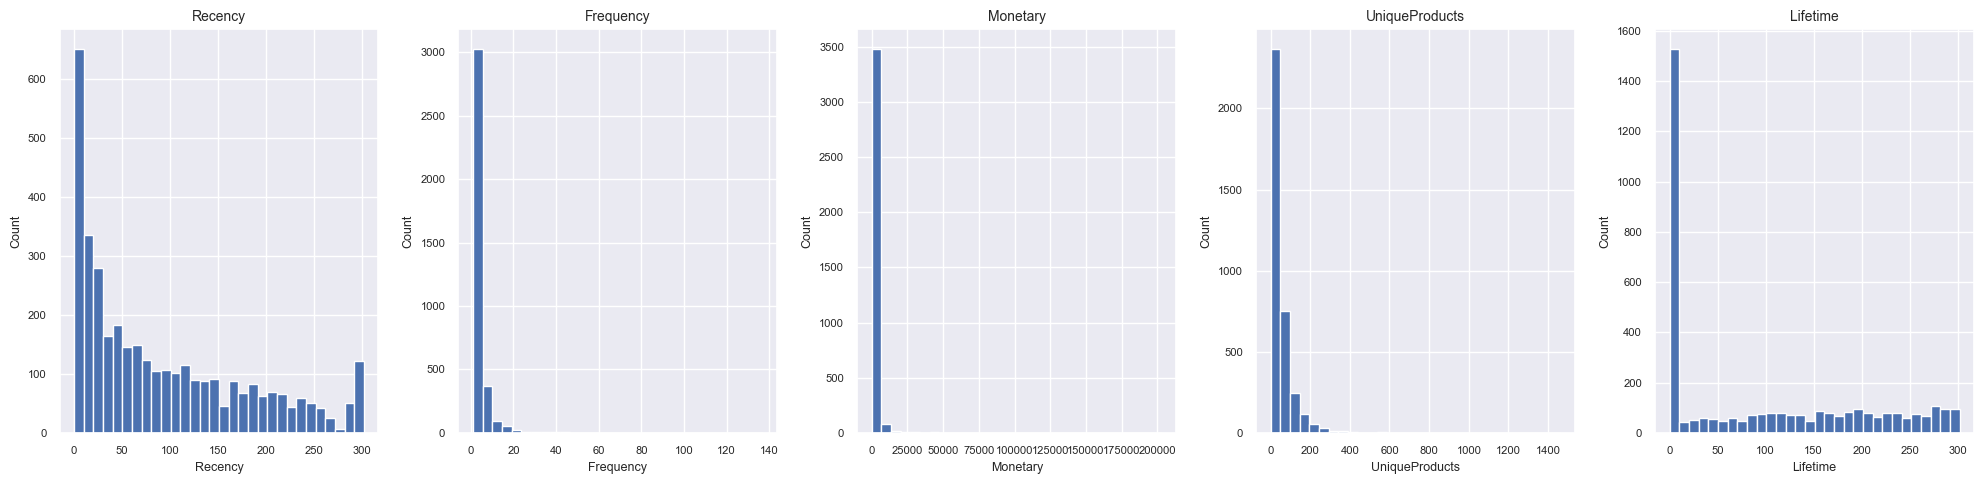

In [281]:
fig, axes = plt.subplots(1, len(numerical_cols), figsize=(20, 5))

for ax, col in zip(axes, numerical_cols):
    ax.hist(customer_features[col], bins=30)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

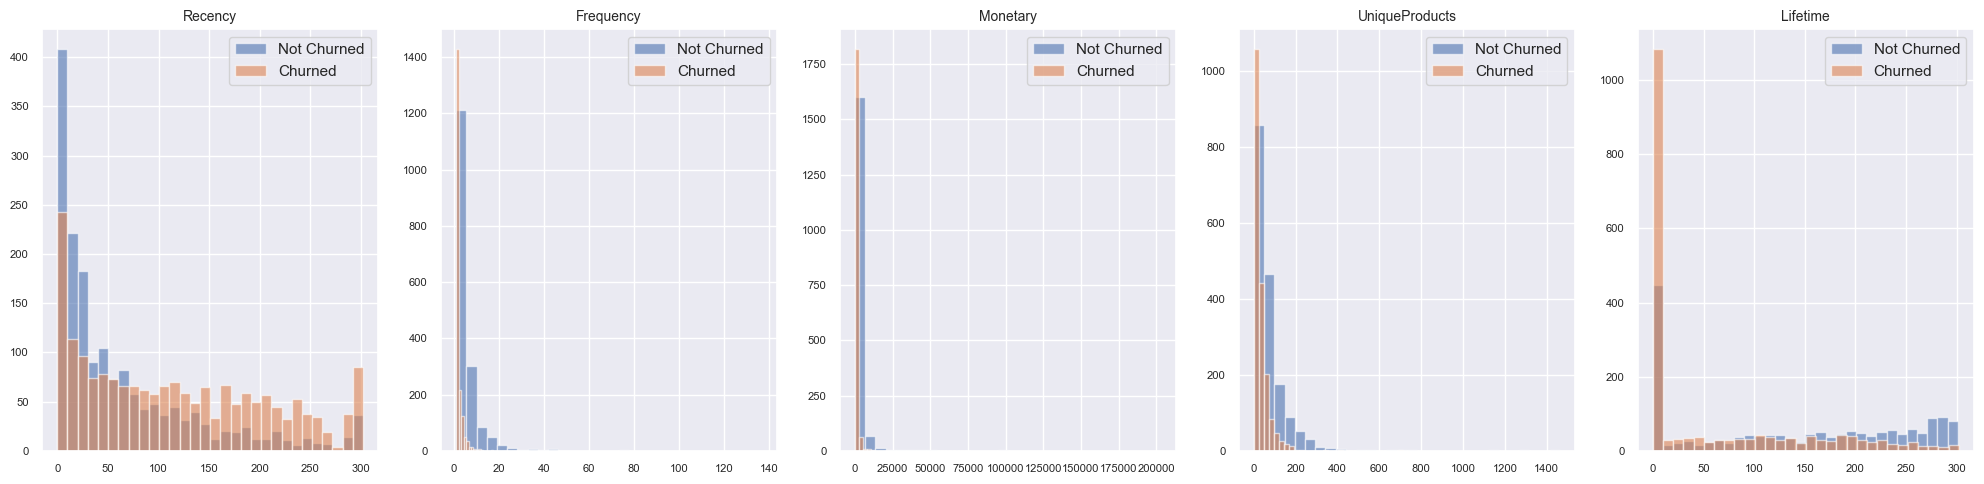

In [282]:
fig, axes = plt.subplots(1, len(numerical_cols), figsize=(20, 5))

for ax, col in zip(axes, numerical_cols):
    ax.hist(
        customer_features.loc[customer_features["Churn"] == 0, col],
        bins=30,
        alpha=0.6,
        label="Not Churned"
    )
    ax.hist(
        customer_features.loc[customer_features["Churn"] == 1, col],
        bins=30,
        alpha=0.6,
        label="Churned"
    )
    ax.set_title(col)
    ax.legend()

plt.tight_layout()

plt.show()

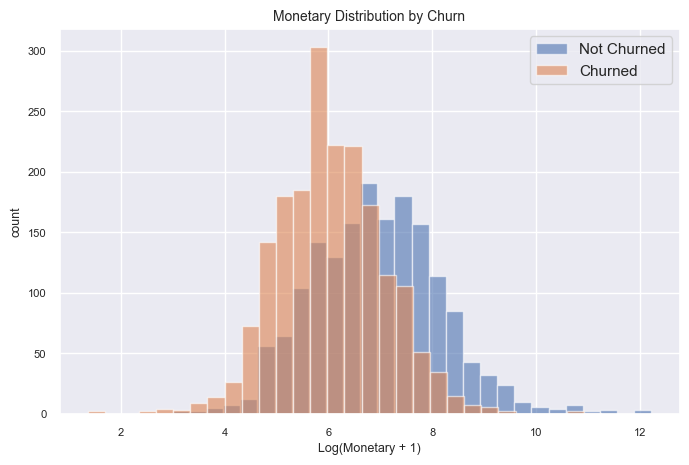

In [283]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    np.log1p(customer_features.loc[customer_features["Churn"] == 0, "Monetary"]),
    bins=30,
    alpha=0.6,
    label="Not Churned"
)

ax.hist(
    np.log1p(customer_features.loc[customer_features["Churn"] == 1, "Monetary"]),
    bins=30,
    alpha=0.6,
    label="Churned"
)

ax.set_title("Monetary Distribution by Churn")
ax.set_xlabel("Log(Monetary + 1)")
ax.set_ylabel("count")
ax.legend()

plt.show()

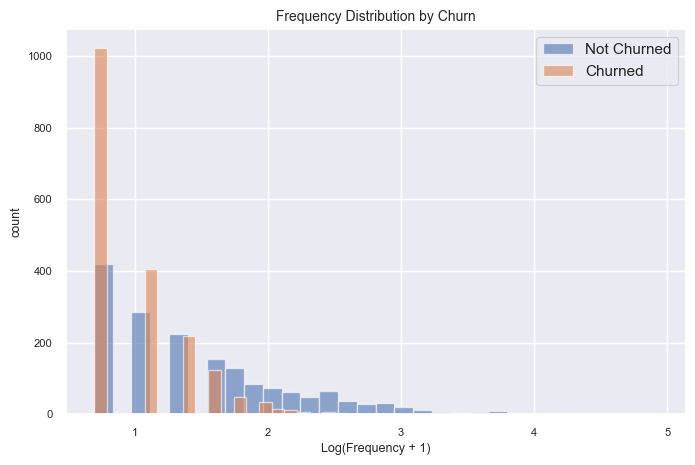

In [284]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    np.log1p(customer_features.loc[customer_features["Churn"] == 0, "Frequency"]),
    bins=30,
    alpha=0.6,
    label="Not Churned"
)

ax.hist(
    np.log1p(customer_features.loc[customer_features["Churn"] == 1, "Frequency"]),
    bins=30,
    alpha=0.6,
    label="Churned"
)

ax.set_title("Frequency Distribution by Churn")
ax.set_xlabel("Log(Frequency + 1)")
ax.set_ylabel("count")
ax.legend()

plt.show()

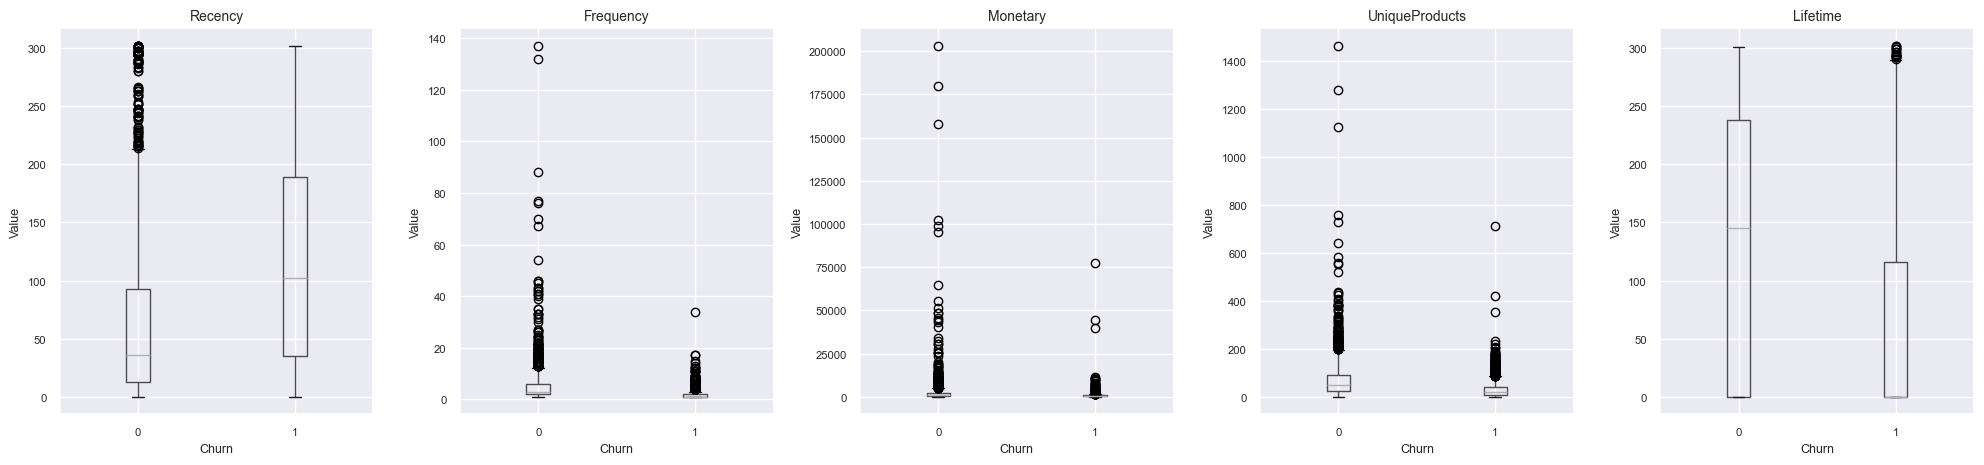

In [285]:
fig, axes = plt.subplots(1, len(numerical_cols), figsize=(20, 5))

for ax, col in zip(axes, numerical_cols):
    customer_features.boxplot(
        column=col,
        by="Churn",
        ax=ax
    )
    ax.set_title(col)
    ax.set_xlabel("Churn")
    ax.set_ylabel("Value")

plt.suptitle("")
plt.tight_layout()

plt.show()

Next, we can add behavioral features to capture **changes in customer behavior**, such as spending and ordering trends.

second question
**2-How does this customer behave?**

## Behavioral Features

| Feature | Meaning |
|---|---|
| `AvgOrderValue` | Average amount the customer spends per order. |
| `ActiveMonths` | Number of different months in which the customer made purchases. |
| `AvgGap` | Average number of days between the customer's purchases. |
| `GapStd` | Measures how consistent the customer's purchase intervals are. |

**In short:** Behavioral features describe **how the customer usually shops**, not just how much they bought.

## AvgGap vs GapStd

### AvgGap
Measures the **average number of days between purchases**.

- Lower `AvgGap` → customer purchases **more frequently**.
- Higher `AvgGap` → customer purchases **less frequently**.

Example:

```text
AvgGap = 5 days  → frequent purchases
AvgGap = 30 days → less frequent
AvgGap = 60 days → very infrequent

In [286]:
# =========================
# Customer Feature Engineering
# =========================

# 1. Average Order Value
order_values = (
    df_obs
    .groupby(["CustomerID", "InvoiceNo"])["TotalPrice"]
    .sum()
    .reset_index(name="OrderValue")
)

avg_order_value = (
    order_values
    .groupby("CustomerID")["OrderValue"]
    .mean()
    .rename("AvgOrderValue")
)

customer_features = customer_features.merge(
    avg_order_value,
    on="CustomerID",
    how="left"
)


# 2. Active Months
df_obs["YearMonth"] = df_obs["InvoiceDate"].dt.to_period("M")

active_months = (
    df_obs
    .groupby("CustomerID")["YearMonth"]
    .nunique()
    .rename("ActiveMonths")
)

customer_features = customer_features.merge(
    active_months,
    on="CustomerID",
    how="left"
)


# 4. Purchase Gap
purchase_dates = (
    df_obs[["CustomerID", "InvoiceDate"]]
    .drop_duplicates()
    .sort_values(["CustomerID", "InvoiceDate"])
)

purchase_dates["GapDays"] = (
    purchase_dates
    .groupby("CustomerID")["InvoiceDate"]
    .diff()
    .dt.days
)

gap_features = (
    purchase_dates
    .groupby("CustomerID")["GapDays"]
    .agg(
        AvgGap="mean",
        GapStd="std"
    )
    .reset_index()
)

customer_features = customer_features.merge(
    gap_features,
    on="CustomerID",
    how="left"
)


# Check
print(customer_features.shape)
print(customer_features.isna().sum())
customer_features.head()

(3604, 13)
CustomerID           0
Recency              0
Frequency            0
Monetary             0
FirstPurchase        0
LastPurchase         0
UniqueProducts       0
Lifetime             0
Churn                0
AvgOrderValue        0
ActiveMonths         0
AvgGap            1442
GapStd            2132
dtype: int64


,CustomerID,Recency,Frequency,Monetary,FirstPurchase,LastPurchase,UniqueProducts,Lifetime,Churn,AvgOrderValue,ActiveMonths,AvgGap,GapStd
0,12346.000,254,1,77183.600,2011-01-18 10:01:00,2011-01-18 10:01:00,1,0,1,77183.600,1,NaN,NaN
1,12347.000,58,5,2790.860,2010-12-07 14:57:00,2011-08-02 08:48:00,82,237,0,558.172,5,58.750,9.535
2,12348.000,4,4,1797.240,2010-12-16 19:09:00,2011-09-25 13:13:00,22,282,1,449.310,4,94.000,70.150
3,12350.000,239,1,334.400,2011-02-02 16:01:00,2011-02-02 16:01:00,17,0,1,334.400,1,NaN,NaN
4,12352.000,1,7,2194.310,2011-02-16 12:33:00,2011-09-28 14:58:00,47,224,0,313.473,3,37.167,70.692


In [287]:
customer_features[["AvgGap", "GapStd"]] = (
    customer_features[["AvgGap", "GapStd"]].fillna(0)
)

In [288]:
customer_features.columns

Index(['CustomerID', 'Recency', 'Frequency', 'Monetary', 'FirstPurchase',
       'LastPurchase', 'UniqueProducts', 'Lifetime', 'Churn', 'AvgOrderValue',
       'ActiveMonths', 'AvgGap', 'GapStd'],
      dtype='object')

**Time for visualizaion**

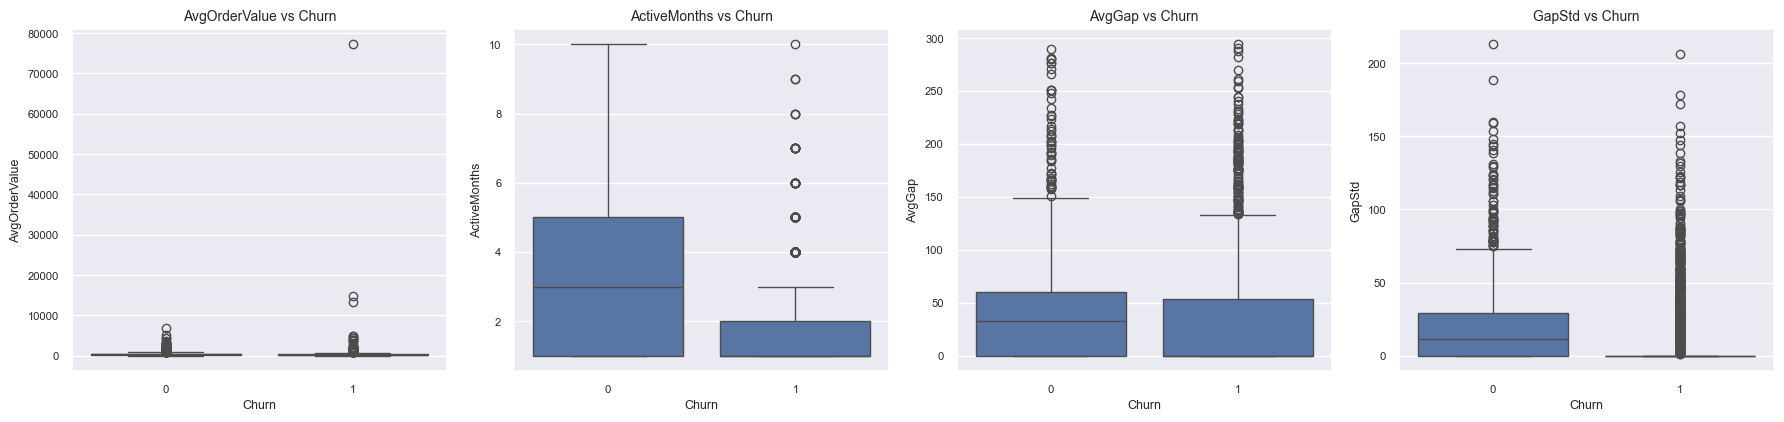

In [289]:
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Numerical Features
# =========================

numerical_cols = [
    "AvgOrderValue",
    "ActiveMonths",
    "AvgGap",
    "GapStd"
]


# =========================
# 1. Features vs Churn
# =========================

fig, axes = plt.subplots(3, 4, figsize=(18, 12))

axes = axes.flatten()

for ax, col in zip(axes, numerical_cols):

    sns.boxplot(
        data=customer_features,
        x="Churn",
        y=col,
        ax=ax
    )

    ax.set_title(f"{col} vs Churn")
    ax.set_xlabel("Churn")
    ax.set_ylabel(col)

# Hide unused plots
for ax in axes[len(numerical_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()




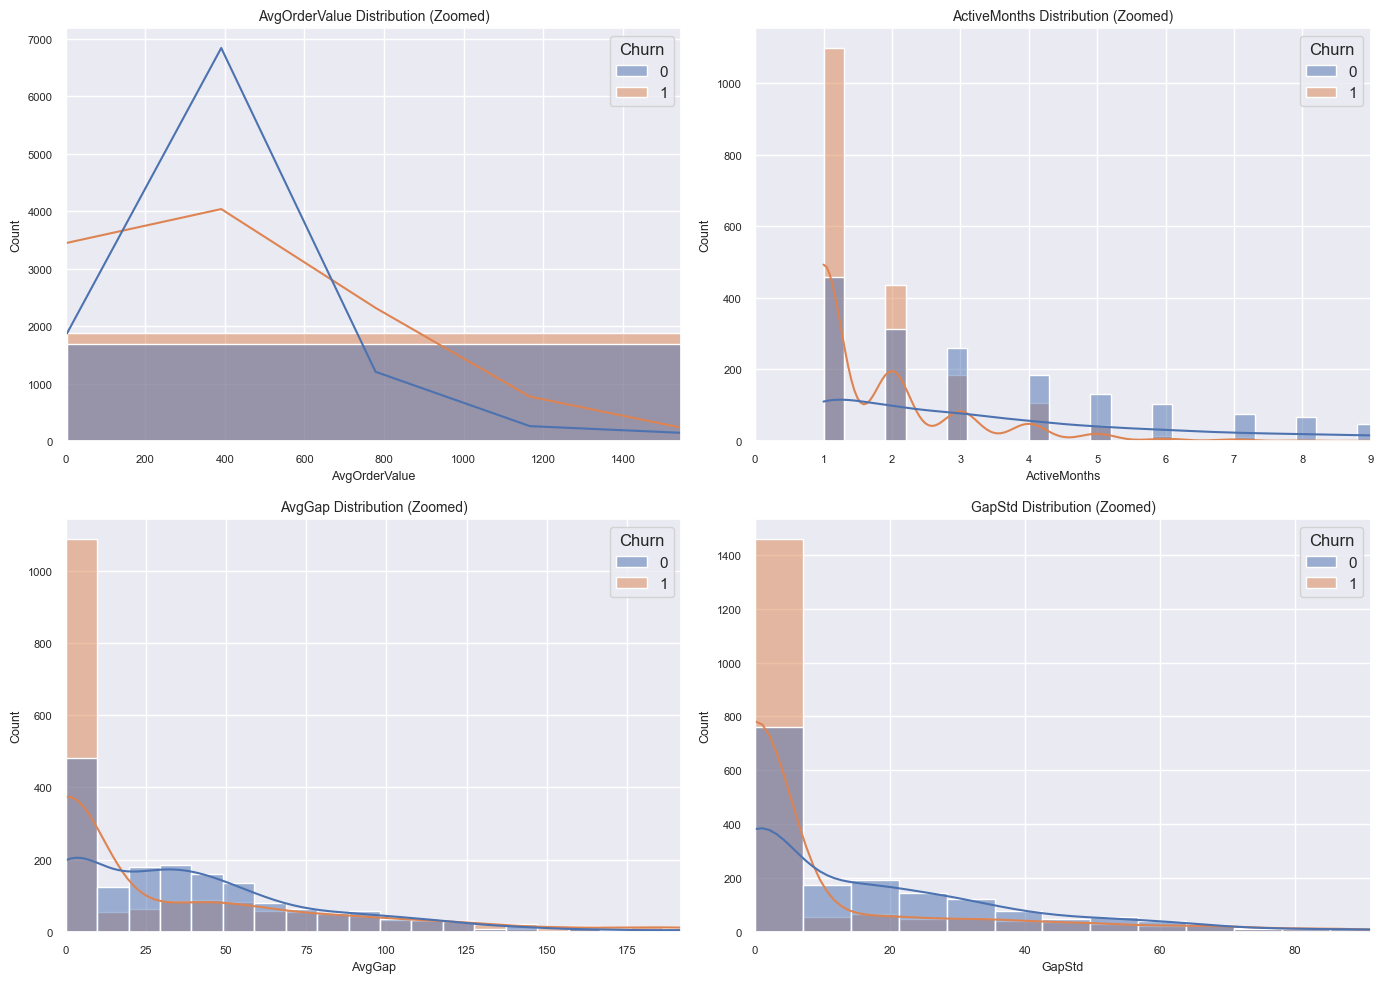

In [290]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, numerical_cols):
    
    upper_limit = customer_features[col].quantile(0.98)
    
    sns.histplot(
        data=customer_features,
        x=col,
        hue="Churn",
        bins=30,
        kde=True,
        alpha=0.5,
        ax=ax
    )

    ax.set_xlim(0, upper_limit)
    

    ax.set_title(f"{col} Distribution (Zoomed)")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

# Hide unused plots
for ax in axes[len(numerical_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

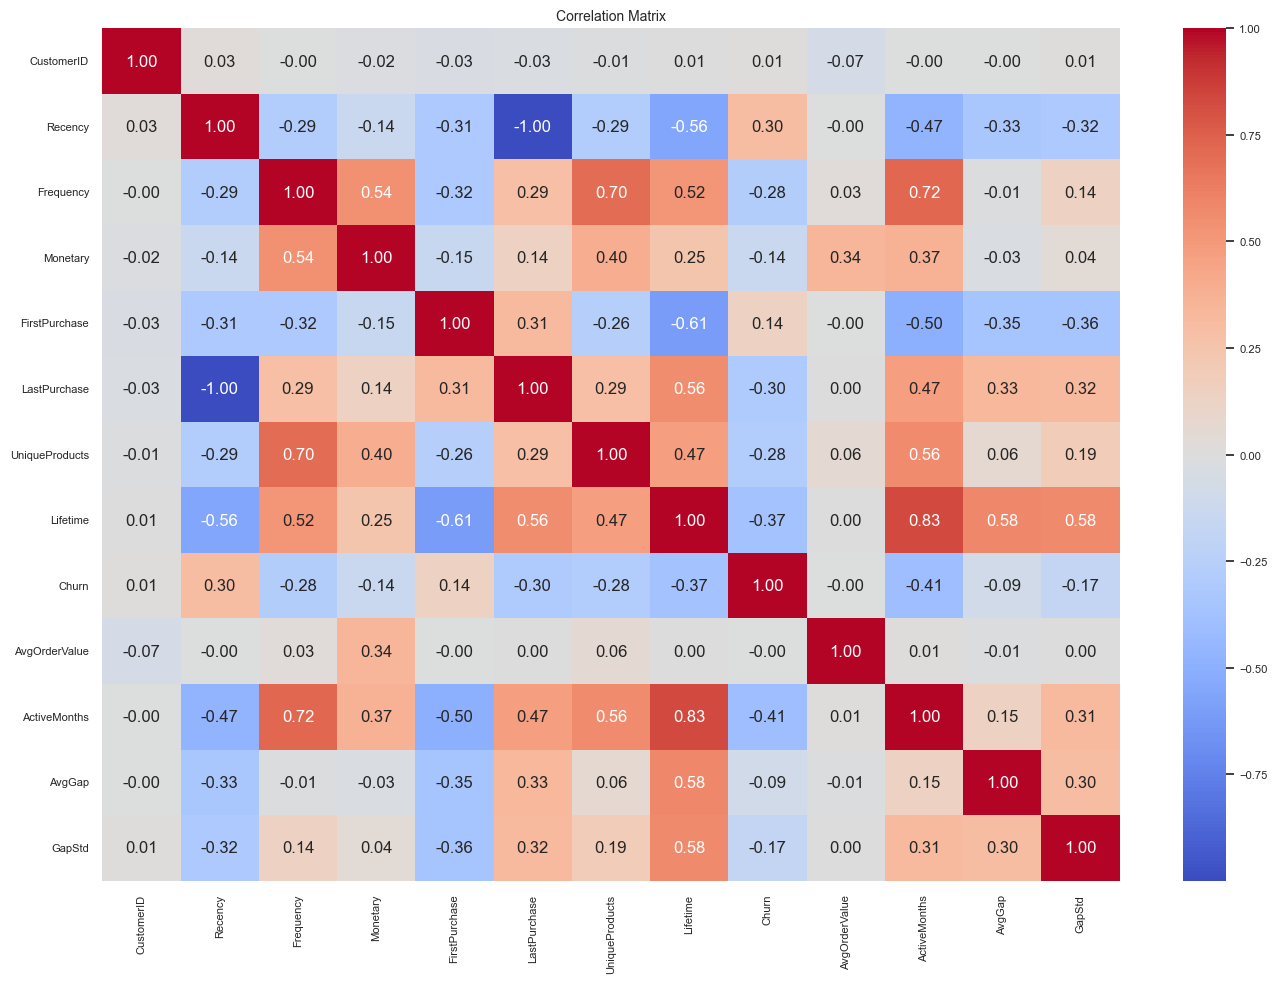

In [291]:
# =========================
# 2. Correlation Matrix
# =========================

corr_matrix = customer_features[
   customer_features.columns
].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## Main Conclusion

The data shows meaningful relationships with customer churn, but there is no
single feature that strongly explains churn on its own.

- `ActiveMonths` (-0.41) is the strongest signal: customers who remain active
  across more months are less likely to churn.
- `Lifetime` (-0.37) and `Recency` (0.30) also provide meaningful signals.
- `Frequency` and `UniqueProducts` (-0.28) show weaker but logical relationships
  with churn.
- `AvgOrderValue` (~0.00) does not have a meaningful linear relationship with churn.

Overall, churn appears to be driven more by **customer engagement and purchase
consistency** than by the amount spent per order.

The correlations between features also show some redundancy, especially
`Recency`/`LastPurchase` and `ActiveMonths`/`Lifetime`.

Therefore, the dataset is not unconnected; rather, **churn is influenced by
multiple behavioral factors instead of one dominant variable**.

## 3- Trend Features

These features compare the customer's behavior between the **first half** and **second half** of the observation period.

- `FirstHalfOrders` → Number of orders in the first half.
- `SecondHalfOrders` → Number of orders in the second half.
- `FirstHalfSpend` → Total spending in the first half.
- `SecondHalfSpend` → Total spending in the second half.

### Trend

- `OrderTrend = SecondHalfOrders - FirstHalfOrders`
  - Positive → orders increased.
  - Negative → orders decreased.

- `SpendTrend = SecondHalfSpend - FirstHalfSpend`
  - Positive → spending increased.
  - Negative → spending decreased.

**In short:** Trend features show whether the customer's **purchasing activity is improving or declining over time**.

In [292]:
# =========================
# Trend Features
# =========================

midpoint = (
    df_obs["InvoiceDate"].min()
    + (df_obs["InvoiceDate"].max() - df_obs["InvoiceDate"].min()) / 2
)

# First half
first_half = df_obs[df_obs["InvoiceDate"] <= midpoint]

first_half_orders = (
    first_half.groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .rename("FirstHalfOrders")
)

first_half_spend = (
    first_half.groupby("CustomerID")["TotalPrice"]
    .sum()
    .rename("FirstHalfSpend")
)


# Second half
second_half = df_obs[df_obs["InvoiceDate"] > midpoint]

second_half_orders = (
    second_half.groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .rename("SecondHalfOrders")
)

second_half_spend = (
    second_half.groupby("CustomerID")["TotalPrice"]
    .sum()
    .rename("SecondHalfSpend")
)


# Merge
customer_features = customer_features.merge(
    first_half_orders,
    on="CustomerID",
    how="left"
)

customer_features = customer_features.merge(
    second_half_orders,
    on="CustomerID",
    how="left"
)

customer_features = customer_features.merge(
    first_half_spend,
    on="CustomerID",
    how="left"
)

customer_features = customer_features.merge(
    second_half_spend,
    on="CustomerID",
    how="left"
)


# Customers with no activity in a half
customer_features[
    ["FirstHalfOrders", "SecondHalfOrders",
     "FirstHalfSpend", "SecondHalfSpend"]
] = customer_features[
    ["FirstHalfOrders", "SecondHalfOrders",
     "FirstHalfSpend", "SecondHalfSpend"]
].fillna(0)


# Trend
customer_features["OrderTrend"] = (
    customer_features["SecondHalfOrders"]
    - customer_features["FirstHalfOrders"]
)

customer_features["SpendTrend"] = (
    customer_features["SecondHalfSpend"]
    - customer_features["FirstHalfSpend"]
)

In [293]:
customer_features.head()

,CustomerID,Recency,Frequency,Monetary,FirstPurchase,LastPurchase,UniqueProducts,Lifetime,Churn,AvgOrderValue,ActiveMonths,AvgGap,GapStd,FirstHalfOrders,SecondHalfOrders,FirstHalfSpend,SecondHalfSpend,OrderTrend,SpendTrend
0,12346.000,254,1,77183.600,2011-01-18 10:01:00,2011-01-18 10:01:00,1,0,1,77183.600,1,0.000,0.000,1.000,0.000,77183.600,0.000,-1.000,-77183.600
1,12347.000,58,5,2790.860,2010-12-07 14:57:00,2011-08-02 08:48:00,82,237,0,558.172,5,58.750,9.535,3.000,2.000,1823.430,967.430,-1.000,-856.000
2,12348.000,4,4,1797.240,2010-12-16 19:09:00,2011-09-25 13:13:00,22,282,1,449.310,4,94.000,70.150,3.000,1.000,1487.240,310.000,-2.000,-1177.240
3,12350.000,239,1,334.400,2011-02-02 16:01:00,2011-02-02 16:01:00,17,0,1,334.400,1,0.000,0.000,1.000,0.000,334.400,0.000,-1.000,-334.400
4,12352.000,1,7,2194.310,2011-02-16 12:33:00,2011-09-28 14:58:00,47,224,0,313.473,3,37.167,70.692,5.000,2.000,1561.810,632.500,-3.000,-929.310


**visualization**

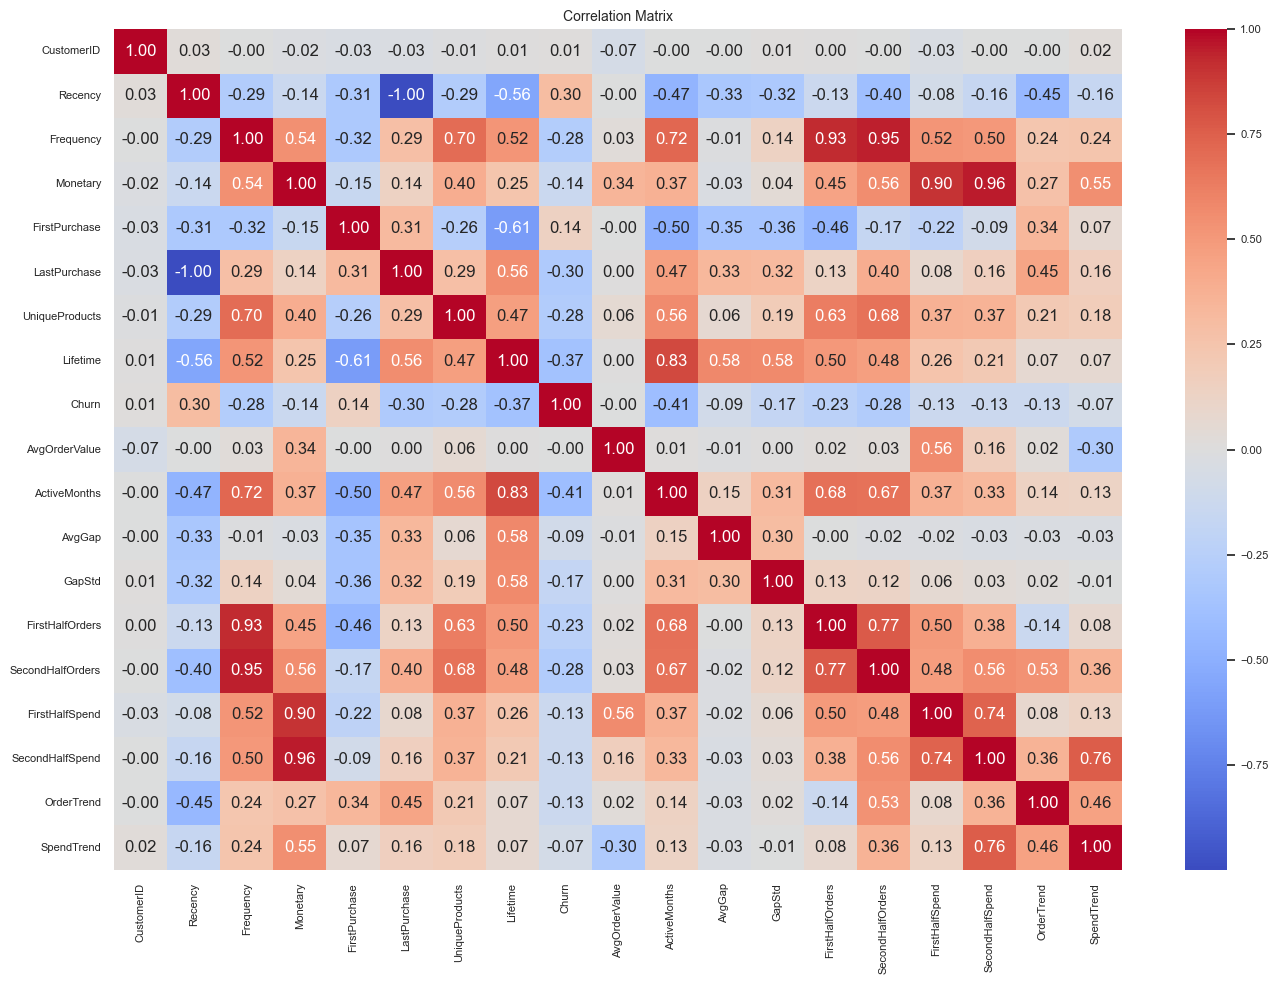

In [294]:
# =========================
# 2. Correlation Matrix
# =========================

corr_matrix = customer_features[
   customer_features.columns
].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [295]:
# =========================
# Recent Behavior + Trend Features
# =========================

# Define recent period: last 3 months of observation
observation_start = df_obs["InvoiceDate"].min()
observation_end = df_obs["InvoiceDate"].max()

recent_start = observation_end - pd.Timedelta(days=90)

df_recent = df_obs[
    df_obs["InvoiceDate"] >= recent_start
].copy()

df_older = df_obs[
    df_obs["InvoiceDate"] < recent_start
].copy()


# -------------------------
# Recent Orders
# -------------------------

recent_orders = (
    df_recent.groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .rename("RecentOrders")
)

recent_spend = (
    df_recent.groupby("CustomerID")["TotalPrice"]
    .sum()
    .rename("RecentSpend")
)


# -------------------------
# Older Orders & Spend
# -------------------------

older_orders = (
    df_older.groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .rename("OlderOrders")
)

older_spend = (
    df_older.groupby("CustomerID")["TotalPrice"]
    .sum()
    .rename("OlderSpend")
)


# -------------------------
# Merge
# -------------------------

customer_features = customer_features.merge(
    recent_orders,
    on="CustomerID",
    how="left"
)

customer_features = customer_features.merge(
    recent_spend,
    on="CustomerID",
    how="left"
)

customer_features = customer_features.merge(
    older_orders,
    on="CustomerID",
    how="left"
)

customer_features = customer_features.merge(
    older_spend,
    on="CustomerID",
    how="left"
)


# Customers with no activity
cols = [
    "RecentOrders",
    "RecentSpend",
    "OlderOrders",
    "OlderSpend"
]

customer_features[cols] = (
    customer_features[cols]
    .fillna(0)
)


# -------------------------
# Recent Activity Ratios
# -------------------------

customer_features["RecentOrderRatio"] = (
    customer_features["RecentOrders"]
    / customer_features["Frequency"]
)

customer_features["RecentSpendRatio"] = (
    customer_features["RecentSpend"]
    / customer_features["Monetary"]
)


# -------------------------
# Trend Rates
# -------------------------

customer_features["OrderTrendRate"] = (
    (customer_features["RecentOrders"] -
     customer_features["OlderOrders"])
    / (customer_features["OlderOrders"] + 1)
)

customer_features["SpendTrendRate"] = (
    (customer_features["RecentSpend"] -
     customer_features["OlderSpend"])
    / (customer_features["OlderSpend"] + 1)
)

In [296]:
customer_features.head()

,CustomerID,Recency,Frequency,Monetary,FirstPurchase,LastPurchase,UniqueProducts,Lifetime,Churn,AvgOrderValue,ActiveMonths,AvgGap,GapStd,FirstHalfOrders,SecondHalfOrders,FirstHalfSpend,SecondHalfSpend,OrderTrend,SpendTrend,RecentOrders,RecentSpend,OlderOrders,OlderSpend,RecentOrderRatio,RecentSpendRatio,OrderTrendRate,SpendTrendRate
0,12346.000,254,1,77183.600,2011-01-18 10:01:00,2011-01-18 10:01:00,1,0,1,77183.600,1,0.000,0.000,1.000,0.000,77183.600,0.000,-1.000,-77183.600,0.000,0.000,1.000,77183.600,0.000,0.000,-0.500,-1.000
1,12347.000,58,5,2790.860,2010-12-07 14:57:00,2011-08-02 08:48:00,82,237,0,558.172,5,58.750,9.535,3.000,2.000,1823.430,967.430,-1.000,-856.000,1.000,584.910,4.000,2205.950,0.200,0.210,-0.600,-0.735
2,12348.000,4,4,1797.240,2010-12-16 19:09:00,2011-09-25 13:13:00,22,282,1,449.310,4,94.000,70.150,3.000,1.000,1487.240,310.000,-2.000,-1177.240,1.000,310.000,3.000,1487.240,0.250,0.172,-0.500,-0.791
3,12350.000,239,1,334.400,2011-02-02 16:01:00,2011-02-02 16:01:00,17,0,1,334.400,1,0.000,0.000,1.000,0.000,334.400,0.000,-1.000,-334.400,0.000,0.000,1.000,334.400,0.000,0.000,-0.500,-0.997
4,12352.000,1,7,2194.310,2011-02-16 12:33:00,2011-09-28 14:58:00,47,224,0,313.473,3,37.167,70.692,5.000,2.000,1561.810,632.500,-3.000,-929.310,2.000,632.500,5.000,1561.810,0.286,0.288,-0.500,-0.595


In [297]:
customer_features["AvgGap"] = (
    customer_features["AvgGap"].fillna(0)
)

customer_features["GapStd"] = (
    customer_features["GapStd"].fillna(0)
)

In [298]:
customer_features.head()

,CustomerID,Recency,Frequency,Monetary,FirstPurchase,LastPurchase,UniqueProducts,Lifetime,Churn,AvgOrderValue,ActiveMonths,AvgGap,GapStd,FirstHalfOrders,SecondHalfOrders,FirstHalfSpend,SecondHalfSpend,OrderTrend,SpendTrend,RecentOrders,RecentSpend,OlderOrders,OlderSpend,RecentOrderRatio,RecentSpendRatio,OrderTrendRate,SpendTrendRate
0,12346.000,254,1,77183.600,2011-01-18 10:01:00,2011-01-18 10:01:00,1,0,1,77183.600,1,0.000,0.000,1.000,0.000,77183.600,0.000,-1.000,-77183.600,0.000,0.000,1.000,77183.600,0.000,0.000,-0.500,-1.000
1,12347.000,58,5,2790.860,2010-12-07 14:57:00,2011-08-02 08:48:00,82,237,0,558.172,5,58.750,9.535,3.000,2.000,1823.430,967.430,-1.000,-856.000,1.000,584.910,4.000,2205.950,0.200,0.210,-0.600,-0.735
2,12348.000,4,4,1797.240,2010-12-16 19:09:00,2011-09-25 13:13:00,22,282,1,449.310,4,94.000,70.150,3.000,1.000,1487.240,310.000,-2.000,-1177.240,1.000,310.000,3.000,1487.240,0.250,0.172,-0.500,-0.791
3,12350.000,239,1,334.400,2011-02-02 16:01:00,2011-02-02 16:01:00,17,0,1,334.400,1,0.000,0.000,1.000,0.000,334.400,0.000,-1.000,-334.400,0.000,0.000,1.000,334.400,0.000,0.000,-0.500,-0.997
4,12352.000,1,7,2194.310,2011-02-16 12:33:00,2011-09-28 14:58:00,47,224,0,313.473,3,37.167,70.692,5.000,2.000,1561.810,632.500,-3.000,-929.310,2.000,632.500,5.000,1561.810,0.286,0.288,-0.500,-0.595


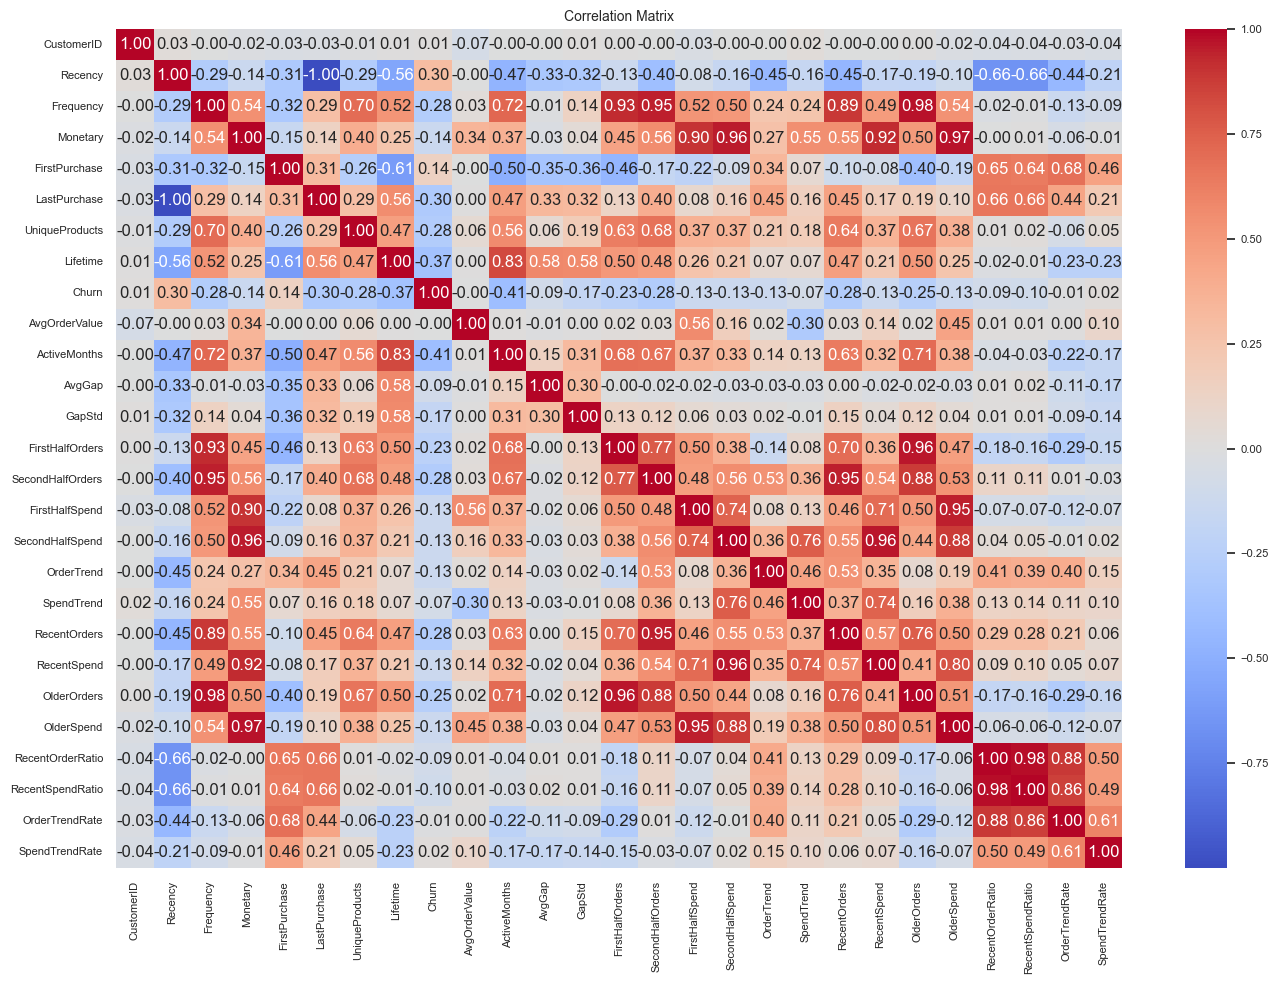

In [299]:
# =========================
# 2. Correlation Matrix
# =========================

corr_matrix = customer_features[
   customer_features.columns
].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [300]:
customer_features = customer_features.drop(
    columns=["LastPurchase"]
)

### Why Remove `LastPurchase`?

- `LastPurchase` and `Recency` have **-1.00 correlation**.
- Both represent the customer's last purchase timing.
- `Recency` directly measures **days since last purchase**, making it more useful for churn.

→ Keep `Recency` and drop `LastPurchase` to avoid redundancy.

In [301]:
customer_features["Churn"].value_counts(normalize=True)

Churn
1   0.527
0   0.473
Name: proportion, dtype: float64

In [302]:
customer_features.groupby("Churn")[
    [
        "Recency",
        "Frequency",
        "Monetary",
        "RecentOrders",
        "RecentSpend",
        "RecentOrderRatio",
        "RecentSpendRatio",
        "OrderTrendRate",
        "SpendTrendRate"
    ]
].median()

,Recency,Frequency,Monetary,RecentOrders,RecentSpend,RecentOrderRatio,RecentSpendRatio,OrderTrendRate,SpendTrendRate
Churn,,,,,,,,,
0,36.000,3.000,985.790,1.000,346.300,0.333,0.320,-0.400,-0.528
1,102.000,1.000,400.540,0.000,0.000,0.000,0.000,-0.500,-0.990


In [303]:
# feature_cols = [
#     "Recency",
#     "Frequency",
#     "Monetary",
#     "TotalQuantity",
#     "UniqueProducts",
#     "AvgUnitPrice",
#     "CustomerLifetime",
#     "AvgOrderValue",
#     "AvgQuantityPerOrder",
#     "PurchaseRate",
#     "ActiveMonths",
#     "AvgGap",
#     "GapStd",
#     "RecentOrders",
#     "RecentSpend",
#     "RecentOrderRatio",
#     "RecentSpendRatio",
#     "OrderTrendRate",
#     "SpendTrendRate"
# ]
# feature_cols = [
#     "Recency",
#     "Frequency",
#     "Monetary",
#     "UniqueProducts",
#     "Lifetime",
#     "AvgOrderValue",
#     "ActiveMonths",
#     "AvgGap",
#     "GapStd",
#     "RecentOrders",
#     "RecentSpend",
#     "RecentOrderRatio",
#     "RecentSpendRatio",
#     "OrderTrendRate",
#     "SpendTrendRate"
# ]
# feature_cols = [
#     "Monetary",
#     "RecentSpendRatio",
#     "RecentOrderRatio",
#     "Lifetime",
#     "AvgGap",
#     "AvgOrderValue",
#     "UniqueProducts",
#     "SpendTrendRate"
# ]
feature_cols=[  "Recency",
    "Frequency",
    "Monetary",
    "UniqueProducts",
    "Lifetime",
    "AvgOrderValue",
    "ActiveMonths",
    "AvgGap",
    "GapStd",
    # "OrderTrend",
    "SpendTrend"]

In [304]:
x = customer_features[feature_cols]
y = customer_features["Churn"]

In [305]:
x[:5]

,Recency,Frequency,Monetary,UniqueProducts,Lifetime,AvgOrderValue,ActiveMonths,AvgGap,GapStd,SpendTrend
0,254,1,77183.600,1,0,77183.600,1,0.000,0.000,-77183.600
1,58,5,2790.860,82,237,558.172,5,58.750,9.535,-856.000
2,4,4,1797.240,22,282,449.310,4,94.000,70.150,-1177.240
3,239,1,334.400,17,0,334.400,1,0.000,0.000,-334.400
4,1,7,2194.310,47,224,313.473,3,37.167,70.692,-929.310


In [ ]:

# First: separate the final test set
X_temp, X_test, y_temp, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Second: split the remaining data into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.20,
    stratify=y_temp,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nTrain Churn:")
print(y_train.value_counts(normalize=True))

print("\nValidation Churn:")
print(y_val.value_counts(normalize=True))

print("\nTest Churn:")
print(y_test.value_counts(normalize=True))

Train: (2306, 10)
Validation: (577, 10)
Test: (721, 10)

Train Churn:
Churn
1   0.527
0   0.473
Name: proportion, dtype: float64

Validation Churn:
Churn
1   0.527
0   0.473
Name: proportion, dtype: float64

Test Churn:
Churn
1   0.527
0   0.473
Name: proportion, dtype: float64


In [ ]:
from sklearn.preprocessing import QuantileTransformer

baseline_model = Pipeline([
    ("transformer", QuantileTransformer(
        output_distribution="normal",
        random_state=42
    )),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

In [308]:
baseline_model.fit(X_train, y_train)

,steps,"[('transformer', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,n_quantiles,1000
,output_distribution,'normal'
,ignore_implicit_zeros,False
,subsample,10000
,random_state,42
,copy,True
,penalty,'l2'


In [309]:
y_val_prob = baseline_model.predict_proba(X_val)[:, 1]
y_val_pred = (y_val_prob >= 0.5).astype(int)

In [310]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

print("===== VALIDATION =====")

print("Precision :", precision_score(y_val, y_val_pred))
print("Recall    :", recall_score(y_val, y_val_pred))
print("F1 Score  :", f1_score(y_val, y_val_pred))
print("ROC-AUC   :", roc_auc_score(y_val, y_val_prob))
print("PR-AUC    :", average_precision_score(y_val, y_val_prob))

print("\nConfusion Matrix:")

print(confusion_matrix(y_val, y_val_pred))

===== VALIDATION =====
Precision : 0.6713881019830028
Recall    : 0.7796052631578947
F1 Score  : 0.7214611872146118
ROC-AUC   : 0.7468671679197996
PR-AUC    : 0.7573368768275845

Confusion Matrix:
[[157 116]
 [ 67 237]]


In [311]:
coefficients = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": baseline_model.named_steps["model"].coef_[0]
})

coefficients["AbsCoefficient"] = coefficients["Coefficient"].abs()

coefficients = coefficients.sort_values(
    "AbsCoefficient",
    ascending=False
)

coefficients

,Feature,Coefficient,AbsCoefficient
2,Monetary,-0.741,0.741
4,Lifetime,-0.590,0.590
7,AvgGap,0.514,0.514
5,AvgOrderValue,0.479,0.479
3,UniqueProducts,-0.384,0.384
1,Frequency,0.177,0.177
9,SpendTrend,-0.174,0.174
6,ActiveMonths,-0.159,0.159
0,Recency,0.092,0.092
8,GapStd,0.077,0.077


In [312]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import QuantileTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier
)
from sklearn.model_selection import StratifiedKFold, cross_validate

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


# =========================================================
# 1. Define Models
# =========================================================

models = {

    "Logistic Regression": Pipeline([
        ("transformer", QuantileTransformer(
            output_distribution="normal",
            random_state=42
        )),
        ("model", LogisticRegression(
            max_iter=2000,
            random_state=42
        ))
    ]),

    "Random Forest": Pipeline([
        ("transformer", QuantileTransformer(
            output_distribution="normal",
            random_state=42
        )),
        ("model", RandomForestClassifier(
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "HistGradientBoosting": Pipeline([
        ("transformer", QuantileTransformer(
            output_distribution="normal",
            random_state=42
        )),
        ("model", HistGradientBoostingClassifier(
            random_state=42
        ))
    ]),

    "LightGBM": Pipeline([
        ("transformer", QuantileTransformer(
            output_distribution="normal",
            random_state=42
        )),
        ("model", LGBMClassifier(
            random_state=42,
            verbosity=-1,
            n_jobs=-1
        ))
    ]),

}


In [313]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    results.append({
        "Model": name,
        "CV Precision": scores["test_precision"].mean(),
        "CV Recall": scores["test_recall"].mean(),
        "CV F1": scores["test_f1"].mean(),
        "CV ROC-AUC": scores["test_roc_auc"].mean(),
        "CV PR-AUC": scores["test_pr_auc"].mean(),

        "F1 Std": scores["test_f1"].std(),
        "PR-AUC Std": scores["test_pr_auc"].std()
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="CV F1",
    ascending=False
)

results_df

,Model,CV Precision,CV Recall,CV F1,CV ROC-AUC,CV PR-AUC,F1 Std,PR-AUC Std
0,Logistic Regression,0.662,0.788,0.719,0.735,0.723,0.019,0.020
3,LightGBM,0.663,0.732,0.695,0.714,0.693,0.014,0.008
2,HistGradientBoosting,0.665,0.729,0.695,0.715,0.693,0.019,0.016
1,Random Forest,0.665,0.691,0.677,0.711,0.691,0.010,0.014


In [314]:
param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "model__class_weight": [None, "balanced"],
    "model__solver": ["lbfgs", "liblinear"]
}

In [315]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import QuantileTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold

pipeline = Pipeline([
    ("transformer", QuantileTransformer(
        output_distribution="normal",
        random_state=42
    )),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

In [316]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)



Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__C': [0.001, 0.01, ...], 'model__class_weight': [None, 'balanced'], 'model__solver': ['lbfgs', 'liblinear']}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_quantiles,1000


In [317]:
print("Best Parameters:")
print(grid.best_params_)

print("\nBest CV F1:")
print(grid.best_score_)

Best Parameters:
{'model__C': 0.1, 'model__class_weight': None, 'model__solver': 'lbfgs'}

Best CV F1:
0.7222666700243678


In [318]:

best_model = grid.best_estimator_

In [319]:
best_model

,steps,"[('transformer', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,n_quantiles,1000
,output_distribution,'normal'
,ignore_implicit_zeros,False
,subsample,10000
,random_state,42
,copy,True
,penalty,'l2'


In [320]:
best_model = Pipeline([
    ("transformer", QuantileTransformer(
        output_distribution="normal",
        random_state=42
    )),

    ("model", LogisticRegression(
        C=0.1,
        class_weight=None,
        solver="lbfgs",
        max_iter=2000,
        random_state=42
    ))
])

best_model.fit(X_train, y_train)

,steps,"[('transformer', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,n_quantiles,1000
,output_distribution,'normal'
,ignore_implicit_zeros,False
,subsample,10000
,random_state,42
,copy,True
,penalty,'l2'


In [321]:
y_val_proba = best_model.predict_proba(X_val)[:, 1]

In [322]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

thresholds = np.arange(0.10, 0.71, 0.01)

threshold_results = []

for threshold in thresholds:

    y_val_pred = (y_val_proba >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_val, y_val_pred),
        "Recall": recall_score(y_val, y_val_pred),
        "F1": f1_score(y_val, y_val_pred)
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results.sort_values(
    "F1",
    ascending=False
    
).head(10)

,Threshold,Precision,Recall,F1
23,0.330,0.611,0.918,0.733
24,0.340,0.611,0.914,0.733
25,0.350,0.613,0.908,0.732
30,0.400,0.631,0.872,0.732
31,0.410,0.636,0.862,0.732
22,0.320,0.603,0.921,0.729
32,0.420,0.636,0.852,0.729
33,0.430,0.642,0.842,0.728
29,0.390,0.623,0.875,0.728
26,0.360,0.616,0.888,0.728


In [323]:
best_threshold = 0.45

y_test_proba = best_model.predict_proba(X_test)[:, 1]

y_test_pred = (
    y_test_proba >= best_threshold
).astype(int)

In [324]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

print("===== FINAL TEST =====")

print("Threshold :", best_threshold)

print("Precision :",
      precision_score(y_test, y_test_pred))

print("Recall    :",
      recall_score(y_test, y_test_pred))

print("F1 Score  :",
      f1_score(y_test, y_test_pred))

print("ROC-AUC   :",
      roc_auc_score(y_test, y_test_proba))

print("PR-AUC    :",
      average_precision_score(y_test, y_test_proba))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

===== FINAL TEST =====
Threshold : 0.45
Precision : 0.6594488188976378
Recall    : 0.881578947368421
F1 Score  : 0.7545045045045045
ROC-AUC   : 0.7735993208828523
PR-AUC    : 0.7628509899370244

Confusion Matrix:
[[168 173]
 [ 45 335]]


In [325]:
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": best_model.named_steps["model"].coef_[0]
})

coefficients["AbsCoefficient"] = coefficients["Coefficient"].abs()

coefficients.sort_values(
    "AbsCoefficient",
    ascending=False
)

,Feature,Coefficient,AbsCoefficient
4,Lifetime,-0.520,0.520
7,AvgGap,0.502,0.502
2,Monetary,-0.444,0.444
3,UniqueProducts,-0.379,0.379
5,AvgOrderValue,0.280,0.280
6,ActiveMonths,-0.180,0.180
9,SpendTrend,-0.163,0.163
1,Frequency,0.102,0.102
0,Recency,0.100,0.100
8,GapStd,0.055,0.055


## Feature Importance Insights

- `Monetary` → strongest coefficient (**-0.743**)
  Higher customer spending is associated with lower churn risk.

- `Lifetime` → strong negative effect (**-0.595**)
  Longer customer relationships are associated with lower churn.

- `AvgGap` → relatively strong positive effect (**+0.516**)
  Longer gaps between purchases are associated with higher churn risk.

- `AvgOrderValue` → meaningful coefficient (**+0.481**)
  Despite its ~0 correlation with Churn, it contributes to the model.

- `UniqueProducts` → negative effect (**-0.385**)
  More product diversity is associated with lower churn.

- `OrderTrend` → almost no contribution (**-0.016**) -> we may drop it 
  It appears to add very little to this Logistic Regression model.

In [328]:
def predict_churn(
    Recency,
    Frequency,
    Monetary,
    UniqueProducts,
    Lifetime,
    AvgOrderValue,
    ActiveMonths,
    AvgGap,
    GapStd,
    SpendTrend,
    threshold=0.45
):
    data = pd.DataFrame([{
        "Recency": Recency,
        "Frequency": Frequency,
        "Monetary": Monetary,
        "UniqueProducts": UniqueProducts,
        "Lifetime": Lifetime,
        "AvgOrderValue": AvgOrderValue,
        "ActiveMonths": ActiveMonths,
        "AvgGap": AvgGap,
        "GapStd": GapStd,
        "SpendTrend": SpendTrend
    }])

    probability = best_model.predict_proba(data)[0, 1]

    prediction = int(probability >= threshold)

    print(f"Churn Probability: {probability:.2%}")
    print(
        f"Prediction: "
        f"{'Churn' if prediction == 1 else 'Not Churn'}"
    )

    return prediction, probability

In [329]:
predict_churn(
    Recency=20,
    Frequency=10,
    Monetary=3000,
    UniqueProducts=40,
    Lifetime=250,
    AvgOrderValue=500,
    ActiveMonths=8,
    AvgGap=30,
    GapStd=10,
    SpendTrend=-500,
    threshold=0.41
)

Churn Probability: 28.97%
Prediction: Not Churn


(0, np.float64(0.2897473700379582))

In [330]:
predict_churn(
    Recency=180,
    Frequency=2,
    Monetary=300,
    UniqueProducts=5,
    Lifetime=60,
    AvgOrderValue=150,
    ActiveMonths=2,
    AvgGap=90,
    GapStd=50,
    SpendTrend=-250,
    threshold=0.41
)

Churn Probability: 80.69%
Prediction: Churn


(1, np.float64(0.8069379799375227))

In [331]:
import joblib

joblib.dump(best_model, "churn_model.pkl")

['churn_model.pkl']